In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'
TEST_YEAR = '2025'
NUTS2_EL = 'ανατολικης μακεδονιας και θρακης'
MONTH = 'August'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(26128, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL51,EL514,κατω νευροκοπιου,2025,1,23.65882,41.33542,0.075610,0.175080,0.108955,-0.175080,0.153201,0.078964,-0.035746,-0.078964,0.069198,0.078744,0.119839,0.078744,3.335455,4.148710,1.224286,11.500714,13.563043,-0.671905,1.491290,-4.179286,3.874138,6.395217,1.296667,2.820000,-1.477500,7.687426,9.979130,-3.11,7.73,1.510667,9.09,16.91,45.319999,22.74,11.750000,17.500000,41.666667,815.893264,35.0,-7.0,42.0,20.500000,6.000000,22.500000,1.833333,414.0,118.0,0.0,99.07327,178.0,45.0,118.0,86.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2
1,1,EL51,EL514,κατω νευροκοπιου,2025,1,23.65882,41.35339,0.427922,0.094828,-0.379025,-0.094828,0.375043,0.016201,-0.359382,-0.016201,0.056119,0.085830,0.034394,0.085830,4.149310,4.237097,3.898571,13.018571,15.765652,-1.224000,0.631290,-4.642143,1.805862,5.940435,1.342000,2.434194,-0.371786,7.412217,10.853043,-3.11,9.43,1.510667,9.09,16.91,45.319999,22.74,12.958333,21.916667,46.631206,875.021645,39.0,-8.0,47.0,22.833333,7.166667,24.833333,2.833333,414.0,118.0,0.0,99.07327,178.0,45.0,118.0,86.0,31,30,30,10,10,1,6,6,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.0,7.312587,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2
2,2,EL51,EL514,κατω νευροκοπιου,2025,1,23.65882,41.37135,0.254294,-0.039805,-0.292673,0.039805,0.193701,0.278242,-0.161494,-0.278242,0.093497,0.159655,0.097534,0.159655,1.716364,4.631290,2.780909,12.982143,16.475217,0.292353,0.420968,-5.812143,1.661429,4.290000,0.704706,2.526129,-1.515617,7.321786,10.382609,-2.15,7.51,1.510667,9.09,16.91,45.319999,22.74,12.750000,21.833333,49.621212,819.783785,38.0,-6.0,44.0,21.833333,7.000000,23.666667,3.000000,414.0,118.0,0.0,99.07327,178.0,45.0,118.0,86.0,31,30,30,10,10,1,6,6,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.0,1.647387,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2
3,3,EL51,EL514,κατω νευροκοπιου,2025,1,23.68241,41.33542,0.309894,0.033744,-0.230663,-0.033744,0.212940,0.100512,-0.087626,-0.100512,0.067663,0.045576,0.095990,0.045576,3.029310,3.237097,1.936429,11.372759,14.039565,-0.740476,1.164839,-3.339286,2.543103,6.543913,1.182381,2.200968,-0.701429,6.957931,10.291739,-2.89,7.25,1.510667,9.09,16.91,45.319999,22.74,12.083333,17.333333,41.269841,840.138877,35.0,-7.0,42.0,21.000000,6.500000,23.000000,1.833333,414.0,118.0,0.0,99.07327,178.0,45.0,118.0,98.0,14,10,10,4,4,6,4,4,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.0,9.000000,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2
4,4,EL51,EL514,κατω νευροκοπιου,2025,1,23.68241,41.35339,0.303415,-0.110728,-0.305609,0.110728,0.265572,-0.046161,-0.238375,0.046161,0.017036,0.023022,0.017492,0.023022,4.979655,4.337097,5.135000,14.487857,18.555263,-0.919524,-0.055806,-4.226429,2.036207,6.436087,2.009048,2.140645,0.454286,8.262032,12.495675,-2.79,10.09,1.510667,9.09,16.91,45.319999,

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

3266

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

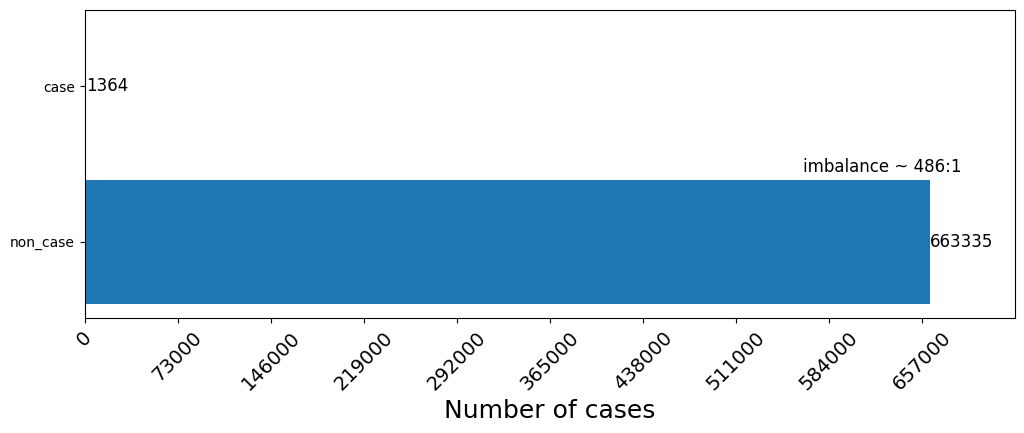

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

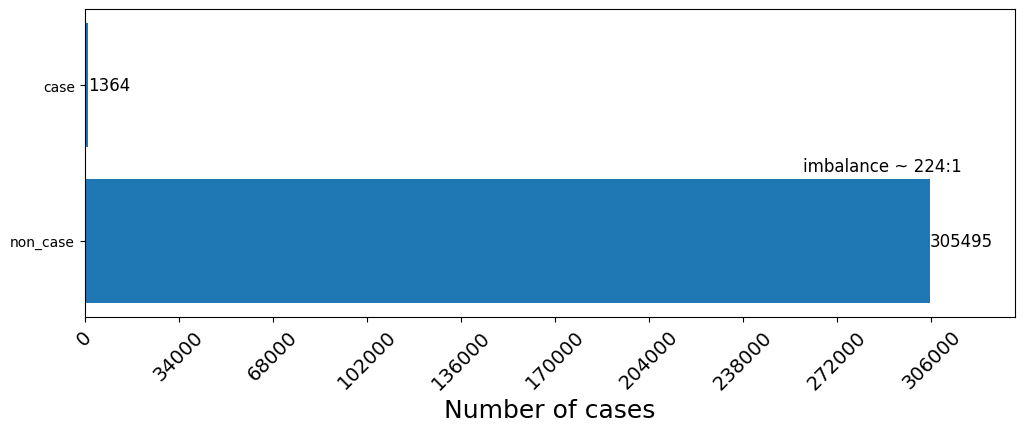

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

In [16]:
# data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# # dataset = dataset.query('month >= 5')
# data_train.reset_index(drop=True, inplace=True)

# plot_imbalance(data_train, target_column='cases')

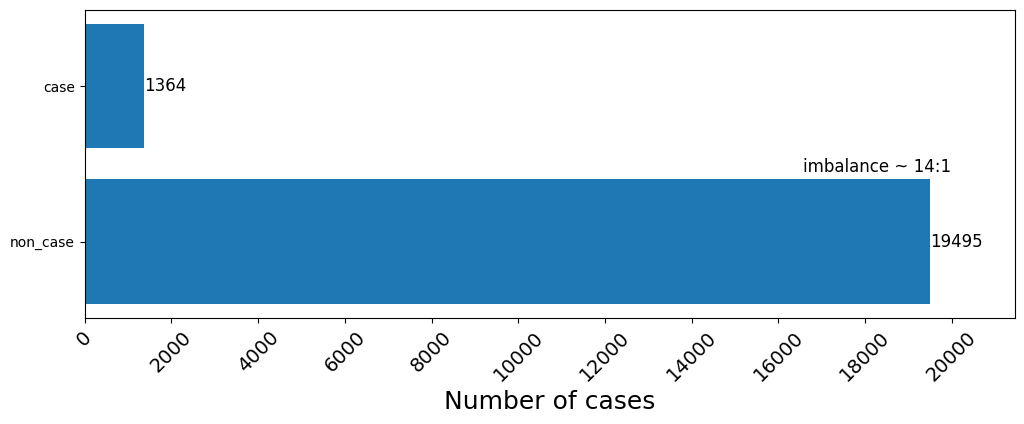

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(20720, 94)

In [19]:
data_train.cases.sum()

1364

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1651,262,1913,6.30%
1,2011,1605,100,1705,16.05%
2,2012,1615,157,1772,10.29%
3,2013,1658,85,1743,19.51%
4,2014,1556,15,1571,103.73%
5,2015,1647,0,1647,inf%
6,2016,1659,0,1659,inf%
7,2017,1588,42,1630,37.81%
8,2018,1570,296,1866,5.30%
9,2019,1651,218,1869,7.57%


In [21]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [22]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 14.29
Weight: 14.29


In [23]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
# data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
# data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [24]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL51,EL514,κατω νευροκοπιου,2025,5,23.65882,41.33542,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,4.148710,1.224286,11.500714,13.563043,6.395217,1.491290,-4.179286,3.874138,6.395217,9.979130,2.820000,-1.477500,7.687426,9.979130,0.59,22.93,3.061667,32.939999,51.639999,91.849998,436.409989,11.750000,17.500000,41.666667,815.893264,35.0,-7.0,42.0,20.500000,6.000000,22.500000,1.833333,414.0,118.0,0.0,99.073270,178.0,45.0,118.0,86.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2,0.500000,-0.866025
1,1,EL51,EL514,κατω νευροκοπιου,2025,5,23.65882,41.35339,0.360191,0.030949,-0.342581,-0.030949,0.355034,-0.009692,-0.337177,0.009692,0.027801,0.053737,0.017200,0.053737,15.765652,4.237097,3.898571,13.018571,15.765652,5.940435,0.631290,-4.642143,1.805862,5.940435,10.853043,2.434194,-0.371786,7.412217,10.853043,0.57,26.19,3.061667,32.939999,51.639999,91.849998,436.409989,12.958333,21.916667,46.631206,875.021645,39.0,-8.0,47.0,22.833333,7.166667,24.833333,2.833333,414.0,118.0,0.0,99.073270,178.0,45.0,118.0,86.0,31,30,30,10,10,1,6,6,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.0,7.312587,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2,0.500000,-0.866025
2,2,EL51,EL514,κατω νευροκοπιου,2025,5,23.65882,41.37135,0.143507,0.386994,-0.173990,-0.386994,0.281733,0.222296,-0.271064,-0.222296,0.092235,0.126367,0.063514,0.126367,16.475217,4.631290,2.780909,12.982143,16.475217,4.290000,0.420968,-5.812143,1.661429,4.290000,10.382609,2.526129,-1.515617,7.321786,10.382609,-0.69,27.17,3.061667,32.939999,51.639999,91.849998,436.409989,12.750000,21.833333,49.621212,819.783785,38.0,-6.0,44.0,21.833333,7.000000,23.666667,3.000000,414.0,118.0,0.0,99.073270,178.0,45.0,118.0,86.0,31,30,30,10,10,1,6,6,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.0,1.647387,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2,0.500000,-0.866025
3,3,EL51,EL514,κατω νευροκοπιου,2025,5,23.68241,41.33542,0.323208,0.258381,-0.279045,-0.258381,0.329267,0.241028,-0.271352,-0.241028,0.045277,0.043576,0.049061,0.043576,14.039565,3.237097,1.936429,11.372759,14.039565,6.543913,1.164839,-3.339286,2.543103,6.543913,10.291739,2.200968,-0.701429,6.957931,10.291739,1.85,23.65,3.061667,32.939999,51.639999,91.849998,436.409989,12.083333,17.333333,41.269841,840.138877,35.0,-7.0,42.0,21.000000,6.500000,23.000000,1.833333,414.0,118.0,0.0,99.073270,178.0,45.0,118.0,98.0,14,10,10,4,4,6,4,4,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.0,9.000000,5775.0,27304.0,9999.0,43078.0,5348.0,25915.0,13125.0,44388.0,NaN,NaN,NaN,2,2,2,0.500000,-0.866025
4,4,EL51,EL514,κατω νευροκοπιου,2025,5,23.68241,41.35339,0.333536,-0.000253,-0.314242,0.000253,0.332275,0.012046,-0.313827,-0.012046,0.046984,0.045939,0.032715,0.045939,18.555263,4.337097,5.

### Results 2025 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
# X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
# X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1710,1710,EL51,EL513,ιασμου,2025,5,25.14498,41.04795,0.053827
1750,1750,EL51,EL513,ιασμου,2025,5,25.19216,41.08389,0.042867
2064,2064,EL51,EL513,αρριανων,2025,5,25.56960,41.11982,0.030158
1771,1771,EL51,EL513,ιασμου,2025,5,25.21575,41.11982,0.029132
1769,1769,EL51,EL513,ιασμου,2025,5,25.21575,41.08389,0.025601


In [32]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
306,306,EL51,EL514,δραμας,2025,6,24.08344,41.17372,0.455165
545,545,EL51,EL514,δραμας,2025,6,24.22498,41.11982,0.160739
544,544,EL51,EL514,δοξατου,2025,6,24.22498,41.10185,0.160386
538,538,EL51,EL514,δοξατου,2025,6,24.22498,40.99405,0.117515
2037,2037,EL51,EL513,αρριανων,2025,6,25.54601,41.11982,0.113182


In [33]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1922,1922,EL51,EL513,κομοτηνης,2025,7,25.42806,41.11982,0.960982
1903,1903,EL51,EL513,κομοτηνης,2025,7,25.40447,41.11982,0.951681
1752,1752,EL51,EL513,ιασμου,2025,7,25.19216,41.11982,0.950268
1771,1771,EL51,EL513,ιασμου,2025,7,25.21575,41.11982,0.948438
1902,1902,EL51,EL513,κομοτηνης,2025,7,25.40447,41.10185,0.938265


In [34]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1770,1770,EL51,EL513,ιασμου,2025,8,25.21575,41.10185,0.951353
2012,2012,EL51,EL513,κομοτηνης,2025,8,25.52242,41.13779,0.948973
2037,2037,EL51,EL513,αρριανων,2025,8,25.54601,41.11982,0.945921
1771,1771,EL51,EL513,ιασμου,2025,8,25.21575,41.11982,0.945720
2220,2220,EL51,EL513,αρριανων,2025,8,25.71114,41.10185,0.940484


In [35]:
# results_sep.sort_values(by='score', ascending=False).head(5)

In [36]:
# results_oct.sort_values(by='score', ascending=False).head(5)

In [37]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [38]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [39]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."


In [40]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL51,"Aνατολική Μακεδονία, Θράκη","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [41]:
greece_lau1.head()

,NAME,geometry
0,Ορεστιάδας,"POLYGON ((26.24076 41.73167, 26.24274 41.73022..."
1,Σουφλίου,"POLYGON ((26.17788 41.37548, 26.17812 41.37442..."
2,Αβδήρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
3,Αλεξανδρούπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
4,Αρριανών,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."


In [42]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,ISMARIDA LAKE,1865103.9,5520.085,"POLYGON ((25.30862 40.99215, 25.30977 40.99238...",0
1,LEFKOGION RESERVOIR,1091876.6,11878.964,"POLYGON ((23.90767 41.40275, 23.90769 41.40308...",1
2,PLATANOBRISI RESERVOIR,3250727.5,40050.050,"POLYGON ((24.37308 41.36354, 24.37362 41.36409...",2
3,THISAVROS RESERVOIR,6928690.5,34912.035,"POLYGON ((24.28272 41.31770, 24.28317 41.31766...",3
4,GRATINI RESERVOIR,1434043.4,12178.949,"POLYGON ((25.51603 41.16096, 25.51670 41.16102...",4


In [43]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
results_jul['x'] = results_jul['x'].round(4)
results_jul['y'] = results_jul['y'].round(4)
results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
results_jul['risk_score'] = results_jul['risk_score'].round(6)

results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
results_aug['x'] = results_aug['x'].round(4)
results_aug['y'] = results_aug['y'].round(4)
results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
results_aug['risk_score'] = results_aug['risk_score'].round(6)

# results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
# results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
# results_sep['x'] = results_sep['x'].round(4)
# results_sep['y'] = results_sep['y'].round(4)
# results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
# results_sep['risk_score'] = results_sep['risk_score'].round(6)

# results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
# results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
# results_oct['x'] = results_oct['x'].round(4)
# results_oct['y'] = results_oct['y'].round(4)
# results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
# results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [44]:
# results_may.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

results_aug.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

# results_sep.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [45]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

In [46]:
grid_index

,cell_number,geometry,centroid,year,month,nuts2,cases
0,F583,"POLYGON ((26.23733 41.70184, 26.23764 41.71084...",POINT (26.24349 41.70622),2018,8,ανατολικης μακεδονιας και θρακης,1
1,F587,"POLYGON ((26.28536 41.70089, 26.28568 41.70989...",POINT (26.29153 41.70527),2019,8,ανατολικης μακεδονιας και θρακης,1
2,AM597,"POLYGON ((26.39446 41.40146, 26.39479 41.41046...",POINT (26.40060 41.40584),2018,8,ανατολικης μακεδονιας και θρακης,1
3,AP595,"POLYGON ((26.36957 41.37496, 26.36990 41.38396...",POINT (26.37571 41.37934),2019,8,ανατολικης μακεδονιας και θρακης,1
4,AQ596,"POLYGON ((26.38119 41.36571, 26.38152 41.37471...",POINT (26.38733 41.37009),2020,9,ανατολικης μακεδονιας και θρακης,1
...,...,...,...,...,...,...,...
1220,RI308,"POLYGON ((22.99525 37.47547, 22.99513 37.48449...",POINT (23.00085 37.48003),2017,7,πελοποννησου,1
1221,RN287,"POLYGON ((22.75854 37.42816, 22.75839 37.43717...",POINT (22.76412 37.43272),2017,7,πελοποννησου,1
1222,AAK447,"POLYGON ((24.55205 35.35088, 24.55211 35.35989...",POINT (24.55758 35.35536),2018,9,κρητης,1
1223,AAP469,"POLYGON ((24.79372 35.30445, 24.79380 35.31347...",POINT (24.79926 35.30892),2018,7,κρητης,1


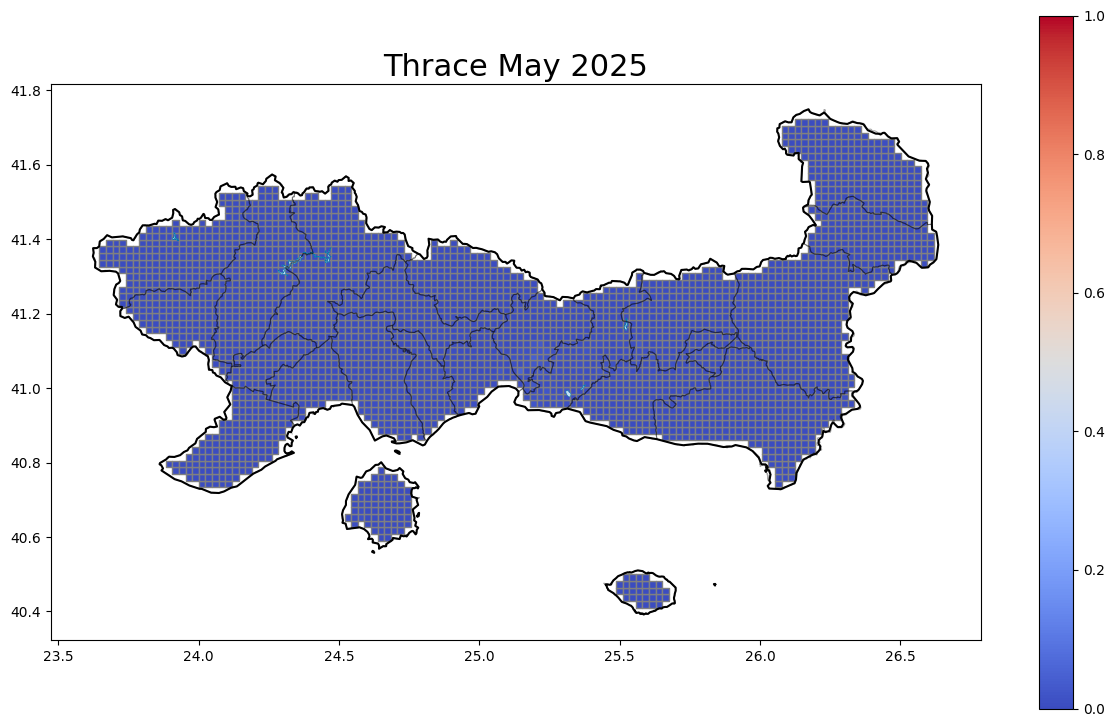

In [47]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [48]:
# results_jun_noise = results_jun.copy()

# from scipy.ndimage import gaussian_filter1d

# # 1. Create random noise
# np.random.seed(42)  # for reproducibility
# raw_noise = np.random.uniform(0.10, 0.50, size=len(results_jun))

# # 2. Smooth the noise so nearby rows have similar values
# smoothed_noise = gaussian_filter1d(raw_noise, sigma=10)  # Increase sigma for smoother variation

# # 3. Add the smoothed noise to the risk_score column
# results_jun_noise['risk_score'] = results_jun['risk_score'] + smoothed_noise

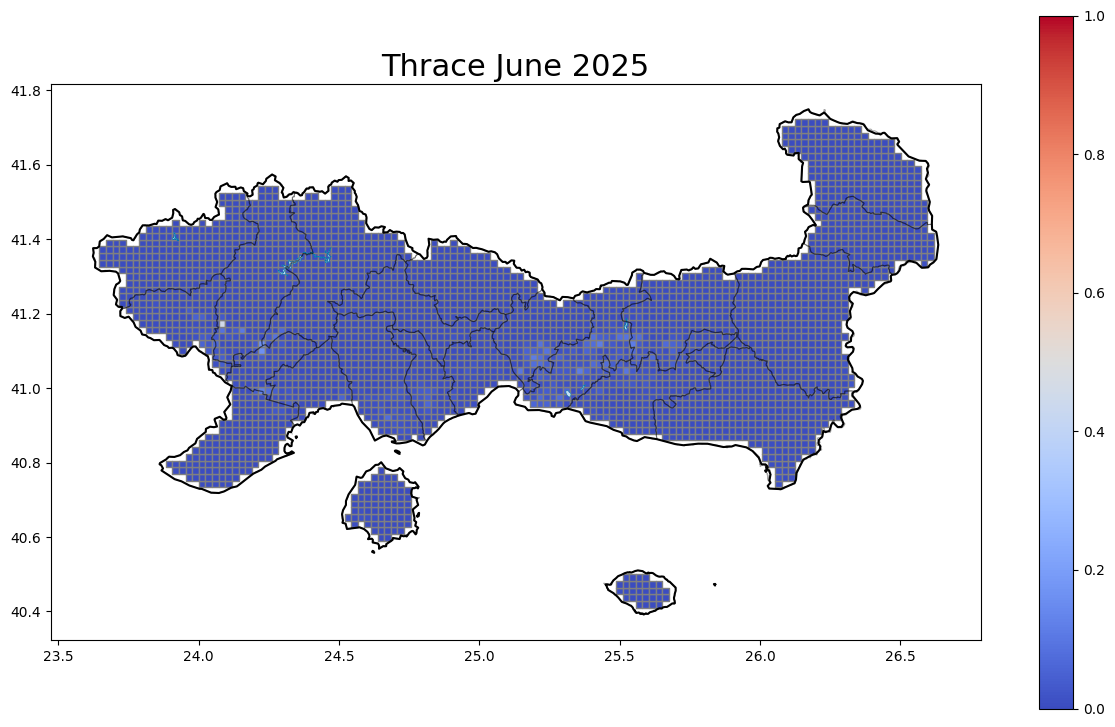

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

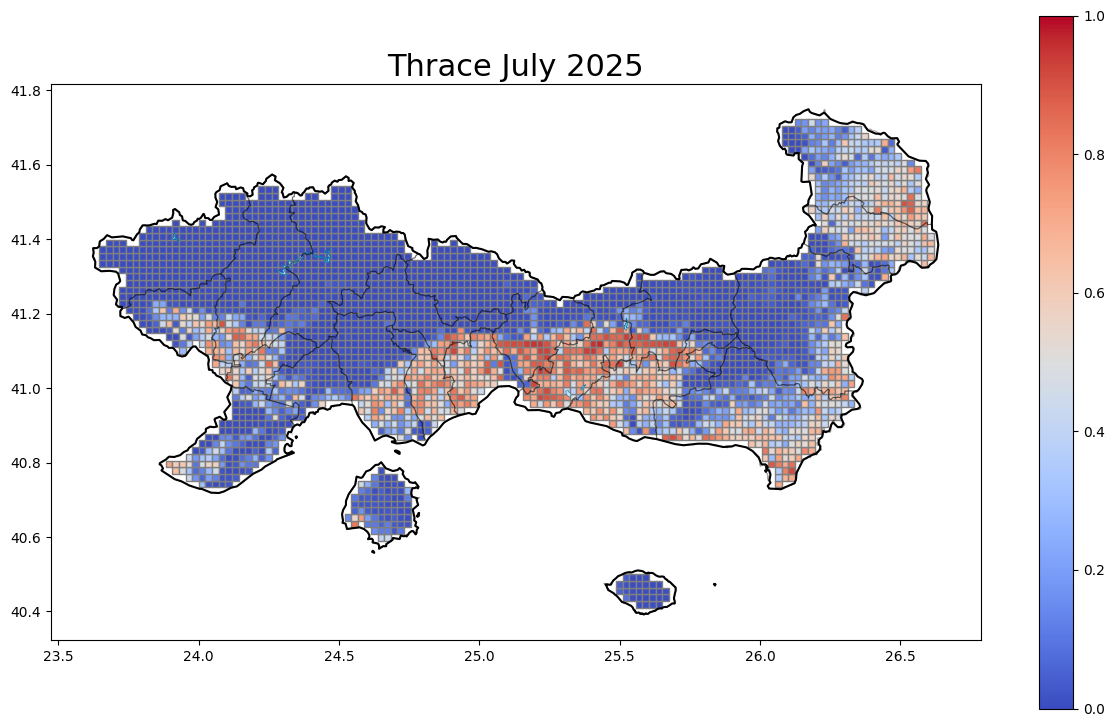

In [50]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

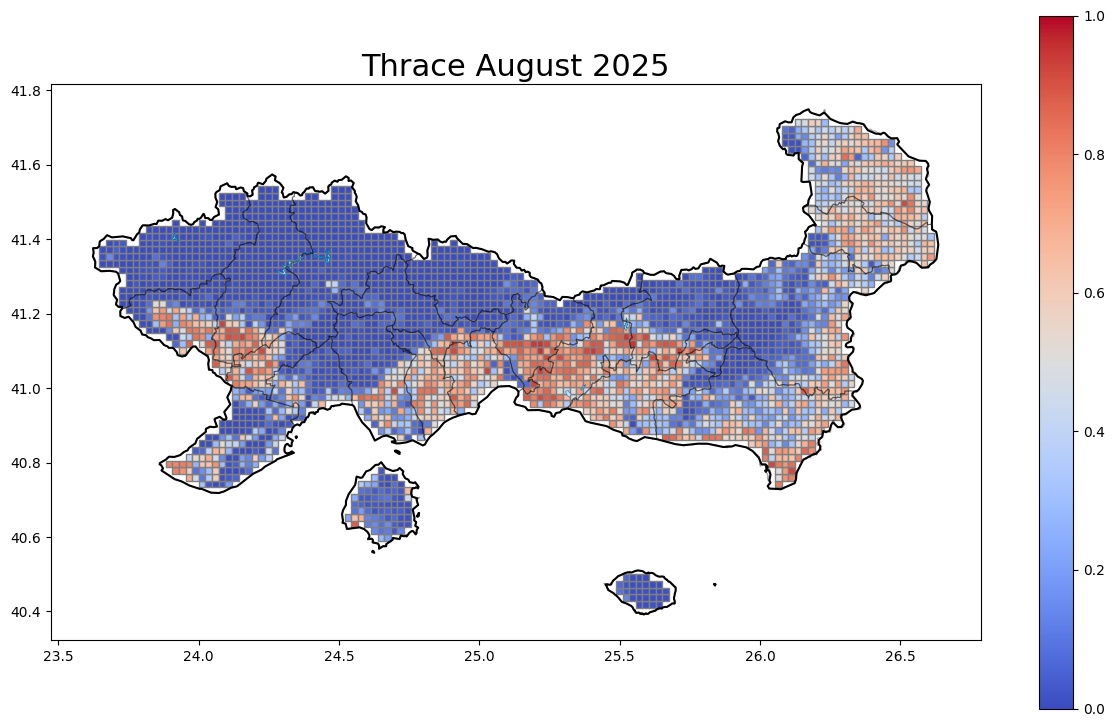

In [51]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [52]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [53]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [54]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_may, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

#================================================================================================================================================

# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [55]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jun, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

#================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [56]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jul, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


#================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [57]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

#================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [58]:
results_may

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL51,EL514,κατω νευροκοπιου,2025,5,23.6588,41.3354,0.000018,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,EL51,EL514,κατω νευροκοπιου,2025,5,23.6588,41.3534,0.000026,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,EL51,EL514,κατω νευροκοπιου,2025,5,23.6588,41.3714,0.000017,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,EL51,EL514,κατω νευροκοπιου,2025,5,23.6824,41.3354,0.000005,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,EL51,EL514,κατω νευροκοπιου,2025,5,23.6824,41.3534,0.000062,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."
...,...,...,...,...,...,...,...,...,...,...
3261,3261,EL51,EL511,ορεστιαδας,2025,5,26.5840,41.4971,0.001507,"POLYGON ((26.59576 41.48814, 26.57217 41.48814..."
3262,3262,EL51,EL511,διδυμοτειχου,2025,5,26.6076,41.3534,0.000669,"POLYGON ((26.61935 41.34440, 26.59576 41.34440..."
3263,3263,EL51,EL511,διδυμοτειχου,2025,5,26.6076,41.3714,0.000614,"POLYGON ((26.61935 41.36237, 26.59576 41.36237..."
3264,3264,EL51,EL511,διδυμοτειχου,2025,5,26.6076,41.3893,0.001989,"POLYGON ((26.61935 41.38034, 26.59576 41.38034..."


In [59]:
# results_may_to_send = results_may[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_may_to_send['cell_id'] = results_may_to_send['nuts3_id'] + '-' + results_may_to_send['cell_number'].astype(str).str.zfill(4)
# results_may_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_may_to_send['lau1'] = results_may_to_send['lau1'].str.upper()
# results_may_to_send = results_may_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_may_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_may_to_send

In [60]:
results_jun

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL51,EL514,κατω νευροκοπιου,2025,6,23.6588,41.3354,0.000021,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,EL51,EL514,κατω νευροκοπιου,2025,6,23.6588,41.3534,0.000055,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,EL51,EL514,κατω νευροκοπιου,2025,6,23.6588,41.3714,0.000035,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,EL51,EL514,κατω νευροκοπιου,2025,6,23.6824,41.3354,0.000002,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,EL51,EL514,κατω νευροκοπιου,2025,6,23.6824,41.3534,0.000155,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."
...,...,...,...,...,...,...,...,...,...,...
3261,3261,EL51,EL511,ορεστιαδας,2025,6,26.5840,41.4971,0.002577,"POLYGON ((26.59576 41.48814, 26.57217 41.48814..."
3262,3262,EL51,EL511,διδυμοτειχου,2025,6,26.6076,41.3534,0.001735,"POLYGON ((26.61935 41.34440, 26.59576 41.34440..."
3263,3263,EL51,EL511,διδυμοτειχου,2025,6,26.6076,41.3714,0.005280,"POLYGON ((26.61935 41.36237, 26.59576 41.36237..."
3264,3264,EL51,EL511,διδυμοτειχου,2025,6,26.6076,41.3893,0.006467,"POLYGON ((26.61935 41.38034, 26.59576 41.38034..."


In [61]:
# results_jun_to_send = results_jun[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_jun_to_send['cell_id'] = results_jun_to_send['nuts3_id'] + '-' + results_jun_to_send['cell_number'].astype(str).str.zfill(4)
# results_jun_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_jun_to_send['lau1'] = results_jun_to_send['lau1'].str.upper()
# results_jun_to_send = results_jun_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_jun_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jun_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_jun_to_send

In [62]:
results_jul

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL51,EL514,κατω νευροκοπιου,2025,7,23.6588,41.3354,0.000168,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,EL51,EL514,κατω νευροκοπιου,2025,7,23.6588,41.3534,0.000121,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,EL51,EL514,κατω νευροκοπιου,2025,7,23.6588,41.3714,0.000103,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,EL51,EL514,κατω νευροκοπιου,2025,7,23.6824,41.3354,0.000013,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,EL51,EL514,κατω νευροκοπιου,2025,7,23.6824,41.3534,0.005404,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."
...,...,...,...,...,...,...,...,...,...,...
3261,3261,EL51,EL511,ορεστιαδας,2025,7,26.5840,41.4971,0.565695,"POLYGON ((26.59576 41.48814, 26.57217 41.48814..."
3262,3262,EL51,EL511,διδυμοτειχου,2025,7,26.6076,41.3534,0.675652,"POLYGON ((26.61935 41.34440, 26.59576 41.34440..."
3263,3263,EL51,EL511,διδυμοτειχου,2025,7,26.6076,41.3714,0.501940,"POLYGON ((26.61935 41.36237, 26.59576 41.36237..."
3264,3264,EL51,EL511,διδυμοτειχου,2025,7,26.6076,41.3893,0.661282,"POLYGON ((26.61935 41.38034, 26.59576 41.38034..."


In [63]:
# results_jul_to_send = results_jul[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_jul_to_send['cell_id'] = results_jul_to_send['nuts3_id'] + '-' + results_jul_to_send['cell_number'].astype(str).str.zfill(4)
# results_jul_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_jul_to_send['lau1'] = results_jul_to_send['lau1'].str.upper()
# results_jul_to_send = results_jul_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_jul_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jul_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_jul_to_send

In [64]:
results_aug

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL51,EL514,κατω νευροκοπιου,2025,8,23.6588,41.3354,0.000274,"POLYGON ((23.67061 41.32644, 23.64702 41.32644..."
1,1,EL51,EL514,κατω νευροκοπιου,2025,8,23.6588,41.3534,0.015144,"POLYGON ((23.67061 41.34440, 23.64702 41.34440..."
2,2,EL51,EL514,κατω νευροκοπιου,2025,8,23.6588,41.3714,0.005744,"POLYGON ((23.67061 41.36237, 23.64702 41.36237..."
3,3,EL51,EL514,κατω νευροκοπιου,2025,8,23.6824,41.3354,0.000081,"POLYGON ((23.69420 41.32644, 23.67061 41.32644..."
4,4,EL51,EL514,κατω νευροκοπιου,2025,8,23.6824,41.3534,0.147870,"POLYGON ((23.69420 41.34440, 23.67061 41.34440..."
...,...,...,...,...,...,...,...,...,...,...
3261,3261,EL51,EL511,ορεστιαδας,2025,8,26.5840,41.4971,0.529753,"POLYGON ((26.59576 41.48814, 26.57217 41.48814..."
3262,3262,EL51,EL511,διδυμοτειχου,2025,8,26.6076,41.3534,0.749944,"POLYGON ((26.61935 41.34440, 26.59576 41.34440..."
3263,3263,EL51,EL511,διδυμοτειχου,2025,8,26.6076,41.3714,0.605550,"POLYGON ((26.61935 41.36237, 26.59576 41.36237..."
3264,3264,EL51,EL511,διδυμοτειχου,2025,8,26.6076,41.3893,0.630558,"POLYGON ((26.61935 41.38034, 26.59576 41.38034..."


In [65]:
results_aug_to_send = results_aug[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_aug_to_send['cell_id'] = results_aug_to_send['nuts3_id'] + '-' + results_aug_to_send['cell_number'].astype(str).str.zfill(4)
results_aug_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_aug_to_send['lau1'] = results_aug_to_send['lau1'].str.upper()
results_aug_to_send = results_aug_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_aug_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Aug_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_aug_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL514-0000,ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ,8,2025,23.6588,41.3354,0.000274
1,EL514-0001,ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ,8,2025,23.6588,41.3534,0.015144
2,EL514-0002,ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ,8,2025,23.6588,41.3714,0.005744
3,EL514-0003,ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ,8,2025,23.6824,41.3354,0.000081
4,EL514-0004,ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ,8,2025,23.6824,41.3534,0.147870
...,...,...,...,...,...,...,...
3261,EL511-3261,ΟΡΕΣΤΙΑΔΑΣ,8,2025,26.5840,41.4971,0.529753
3262,EL511-3262,ΔΙΔΥΜΟΤΕΙΧΟΥ,8,2025,26.6076,41.3534,0.749944
3263,EL511-3263,ΔΙΔΥΜΟΤΕΙΧΟΥ,8,2025,26.6076,41.3714,0.605550
3264,EL511-3264,ΔΙΔΥΜΟΤΕΙΧΟΥ,8,2025,26.6076,41.3893,0.630558


In [66]:
# results_sep

In [67]:
# results_sep_to_send = results_sep[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_sep_to_send['cell_id'] = results_sep_to_send['nuts3_id'] + '-' + results_sep_to_send['cell_number'].astype(str).str.zfill(4)
# results_sep_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_sep_to_send['lau1'] = results_sep_to_send['lau1'].str.upper()
# results_sep_to_send = results_sep_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_sep_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Sep_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_sep_to_send